値　確率
 1. 0.1458
 2. 0.1458
 3. 0.1458
 4. 0.1458
 5. 0.1458
 6. 0.1458
 7. 0.0625
 8. 0.0625


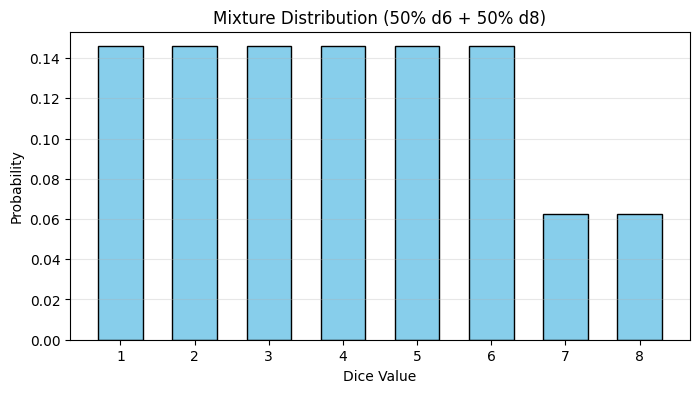

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 各サイコロのPMF

die6 = np.ones(6)/6
die8 = np.ones(8)/8

# x軸
x = np.arange(1,9)

# 混合分布
mixture = np.zeros(8)

# ６面サイコロを50%
mixture[:6] += 0.5 * die6

# 8面サイコロを50%
mixture += 0.5 * die8

# グラフ
plt.figure(figsize=(8,4))

plt.bar(x, mixture, width=0.6, color="skyblue", edgecolor="black")
plt.xticks(x)
plt.xlabel("Dice Value")
plt.ylabel("Probability")
plt.title("Mixture Distribution (50% d6 + 50% d8)")

plt.grid(axis="y", alpha=0.3)

# 結果の表示
print("値　確率")
for value, prob in zip(x, mixture):
    print(f"{value:2d}. {prob:.4f}")


In [ ]:
import thinkbayes

class Die(thinkbayes.Pmf):
    def __init__(self, sides, name=""):
        thinkbayes.Pmf.__init__(self, name=name)
        for x in range(1,sides+1):
            self.Set(x,1)

        self.Normalize()



In [9]:
pmf_dice = thinkbayes.Pmf()
pmf_dice.Set(Die(4), 5)
pmf_dice.Set(Die(6), 4)
pmf_dice.Set(Die(8), 3)
pmf_dice.Set(Die(12), 2)
pmf_dice.Set(Die(20), 1)
pmf_dice.Normalize()

mix = thinkbayes.Pmf()
for die, weight in pmf_dice.Items():
    for outcome, prob in die.Items():
        mix.Incr(outcome, weight*prob)
mix = thinkbayes.MakeMixture(pmf_dice)



Text(0.5, 1.0, '')

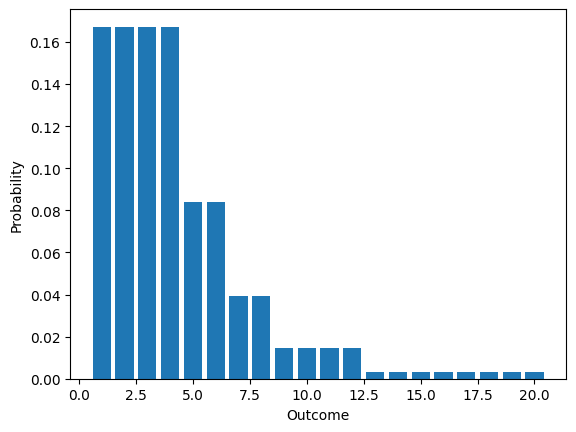

In [14]:
xs, ps = zip(*mix.Items())

plt.bar(xs, ps)
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("")